# 01 - 127-Qubit Kicked Ising on the IBM Eagle Heavy-Hex Lattice

What this notebook answers:

- How do I run the 127-qubit kicked-Ising "utility" benchmark end-to-end in PADO-Pauli,
  with no Julia and no qiskit?
- How do I convince myself the gate/angle conventions and the heavy-hex edge list are right,
  when there is no exact reference at n = 127? (Cross-check a 9-qubit sub-patch of the *same*
  edge list against an exact PennyLane statevector.)
- How do I sweep the transverse field in a **single process** without one hard field taking
  the whole sweep down with it?
- What does the single-site magnetisation curve `<Z_62>` vs field angle look like between the
  two Clifford endpoints?

This is the notebook form of `examples/kicked_ising_127q/` — the same lattice, circuit,
observable and truncation as `run_kicked_ising.py` / `verify_small.py`, imported from those
files rather than re-derived here.

## Notebook Guide / 노트북 가이드

- **EN** This is an application notebook rather than an API walkthrough. Read the `tutorial/`
  notebooks first.
- **KO** 이 노트북은 API 설명이 아니라 응용 예제입니다. `tutorial/` 노트북을 먼저 보는 편이 좋습니다.
- **EN** Section flow: lattice + circuit → 9-qubit exact convention check → 20-field sweep in
  one process → magnetisation curve.
- **KO** 섹션 순서: 격자와 회로 → 9큐빗 exact 규약 검증 → 한 프로세스에서 20개 field 스윕 →
  자화 곡선.
- **EN** Expected outcome: the 9-qubit patch agrees with an exact statevector (checked to 1e-9), and the
  127-qubit curve decays smoothly from `<Z_62> = 1` at `h = 0` to the Clifford value at `h = pi/2`.
- **KO** 기대 결과: 9큐빗 패치가 exact statevector와 1e-9 이내로 일치하고, 127큐빗 곡선이
  `h = 0`의 `<Z_62> = 1`에서 `h = pi/2`의 Clifford 값까지 매끄럽게 감소합니다.
- **EN** Requires a CUDA/ROCm GPU: every compile below uses `preset="gpu"`.
- **KO** CUDA/ROCm GPU가 필요합니다. 아래의 모든 compile은 `preset="gpu"`를 사용합니다.

In [1]:
# EN: Put the kicked_ising_127q bundle on sys.path so its lattice/circuit code can be imported.
# KO: 격자/회로 코드를 import 할 수 있도록 kicked_ising_127q 번들을 sys.path에 추가합니다.
import sys
from pathlib import Path

NB_DIR = Path.cwd()                              # this notebook's directory (examples/)
EXP_DIR = NB_DIR / "kicked_ising_127q"           # batch scripts + recorded results
if str(EXP_DIR) not in sys.path:
    sys.path.insert(0, str(EXP_DIR))             # same import path verify_small.py uses

import warnings
warnings.filterwarnings("ignore")

import json
import time

import torch

import padopauli
from padopauli import pennylane_expvals

use_cuda = torch.cuda.is_available()
NB_PRESET = "gpu"                  # same preset as run_kicked_ising.py
dev = "cuda" if use_cuda else "cpu"
print(f"padopauli {padopauli.__version__}")
print(f"torch {torch.__version__} | cuda available: {use_cuda} | preset: {NB_PRESET}")
if not use_cuda:
    print("WARNING: no CUDA/ROCm device found -- preset='gpu' compiles below will fail.")

import numpy as np
import matplotlib.pyplot as plt

# plot style
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
plt.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# This notebook writes *_notebook.* files: the json to kicked_ising_127q/results/ and the
# figure to examples/figures/. It does not overwrite the recorded results/figures.
RESULTS = EXP_DIR / "results"
FIGS = NB_DIR / "figures"
RESULTS.mkdir(exist_ok=True)
FIGS.mkdir(exist_ok=True)

padopauli 2.0.0
torch 2.11.0+rocm7.2 | cuda available: True | preset: gpu


## 1) The lattice, the circuit, the observable

Everything structural is imported from `run_kicked_ising.py` — the 127-qubit IBM Eagle
heavy-hex edge list (144 edges, taken verbatim from `ibmeagletopology` in
PauliPropagation.jl and converted to 0-indexing), the circuit builder, and the sweep grid.
Nothing about the setup is redefined in this notebook.

One Trotter step is

1. a transverse-field layer, `prod_q exp(-i h X_q / 2)` — one `qc.rx(q, param_idx=0)` per
   qubit, all sharing the single field angle `h`;
2. an Ising layer, `prod_(u,v) exp(+i (pi/4) Z_u Z_v)` = `RZZ(-pi/2)` on every edge — one
   `qc.rzz(u, v, param_idx=1)` per edge, all sharing the fixed angle `-pi/2`.

`RZZ(-pi/2)` is Clifford, so the only branching in the Heisenberg-frame propagation comes
from the field layers. With 20 Trotter steps and the observable `Z_62`, the truncation is
`max_weight = 8` (structural) plus `build_min_abs = 1e-4` (coefficient threshold), matching
`max_weight` / `min_abs_coeff` in Rudolph et al., arXiv:2505.21606 (PauliPropagation.jl
example `3-utility-example.ipynb`).

In [2]:
from run_kicked_ising import (          # definitions shared with the batch scripts
    N, CENTER, NUM_STEPS, RZZ_ANGLE, HS,
    eagle_edges, build_circuit, zero_filtered_terms,
)

MAX_WEIGHT = 8          # = max_weight in Rudolph et al.
MIN_ABS = 1e-4          # = min_abs_coeff in Rudolph et al.

edges = eagle_edges()
qc = build_circuit(edges)               # 20 x (127 RX + 144 RZZ)

print(f"n_qubits = {N}, edges = {len(edges)}, observable = Z_{CENTER}, "
      f"Trotter steps = {NUM_STEPS}")
print(f"gates = {len(qc.gates)}  ({NUM_STEPS} x ({N} RX + {len(edges)} RZZ))")
print(f"field grid: {len(HS)} points, h in [{HS[0]:.4f}, {HS[-1]:.4f}] = LinRange(0, pi/2, 20)")
print(f"truncation: max_weight = {MAX_WEIGHT}, build_min_abs = {MIN_ABS}")

n_qubits = 127, edges = 144, observable = Z_62, Trotter steps = 20
gates = 5420  (20 x (127 RX + 144 RZZ))
field grid: 20 points, h in [0.0000, 1.5708] = LinRange(0, pi/2, 20)
truncation: max_weight = 8, build_min_abs = 0.0001


## 2) Convention check first: 9 qubits, exact statevector

At n = 127 there is no exact reference to compare against, so the conventions get checked
where an exact answer is still available. `verify_small.py` induces a 9-qubit sub-patch of
the `ibmeagletopology` edge list on nodes `{0,1,2,3,4,5,6,14,15}` — which includes
node 4, a degree-3 branch vertex — relabels it to a contiguous range, and runs the same
circuit for 5 Trotter steps.

This tests the edge list as well as the gate conventions: a 0/1-indexing
slip or a mis-transcribed heavy-hex edge would change the induced sub-patch and show up
here. The compile is **untruncated and float64** (no `max_weight`, no `build_min_abs`,
preset default dtype), so any disagreement with the PennyLane statevector is a bug, not a
truncation error.

In [3]:
from verify_small import heavyhex_patch, build as build_patch

node_set = {0, 1, 2, 3, 4, 5, 6, 14, 15}
n_small, edges_small, relabel = heavyhex_patch(node_set)
center_small = relabel[4]                       # the degree-3 branch vertex
steps_small = 5
qc_small = build_patch(n_small, edges_small, steps_small)

degree = {}
for u, v in edges_small:
    degree[u] = degree.get(u, 0) + 1
    degree[v] = degree.get(v, 0) + 1

print(f"heavy-hex patch: n={n_small} edges={len(edges_small)} center={center_small} "
      f"(orig qubit 4, degree {degree[center_small]}) steps={steps_small}")
print(f"  edges (relabelled): {edges_small}")

max_dev = 0.0
for h in [np.pi / 32, np.pi / 8, np.pi / 4, np.pi / 3]:
    thetas_small = torch.tensor([h, RZZ_ANGLE], dtype=torch.float64, device=dev)
    prog_small = qc_small.compile(observables=[("Z", [center_small])],
                                  preset=NB_PRESET, verbosity=0)
    pado = float(prog_small.expval(thetas_small, obs_index=0))
    ref = float(np.asarray(pennylane_expvals(
        circuit=qc_small.gates, observables=prog_small.observables,
        thetas=thetas_small, n_qubits=n_small)).reshape(-1)[0])
    dev_h = abs(pado - ref)
    max_dev = max(max_dev, dev_h)
    print(f"  h={h:.5f} ({h/np.pi:.4f}pi)  pado={pado:+.8f}  "
          f"pennylane={ref:+.8f}  |dev|={dev_h:.2e}")
    prog_small.clear_cache()

print(f"\nmax |pado - pennylane| = {max_dev:.2e}  -> {'PASS' if max_dev < 1e-9 else 'CHECK'}")
assert max_dev < 1e-9

heavy-hex patch: n=9 edges=8 center=4 (orig qubit 4, degree 3) steps=5
  edges (relabelled): [(0, 1), (0, 7), (1, 2), (2, 3), (3, 4), (4, 5), (4, 8), (5, 6)]


  h=0.09817 (0.0312pi)  pado=+0.99527131  pennylane=+0.99527131  |dev|=8.66e-15
  h=0.39270 (0.1250pi)  pado=+0.92743795  pennylane=+0.92743795  |dev|=2.20e-14


  h=0.78540 (0.2500pi)  pado=+0.48337378  pennylane=+0.48337378  |dev|=1.13e-14
  h=1.04720 (0.3333pi)  pado=+0.06253815  pennylane=+0.06253815  |dev|=1.39e-15

max |pado - pennylane| = 2.20e-14  -> PASS


## 3) The 20-field sweep, in one process

`run_sweep.sh` spends one OS process per field on purpose: an out-of-memory failure on a
hard field then kills only that process, and the remaining fields still run. A notebook has
only one process, so that protection has to be rebuilt in-process:

- each field is wrapped in `try/except (RuntimeError, MemoryError)` — a failure records `nan`
  for that field and the loop continues;
- `torch.cuda.empty_cache()` runs between fields so a big field does not leave its
  allocator blocks behind for the next one;
- results are written to disk after every field, so an interrupted run keeps what it had.

The field order is the shell script's ends-inward order `0 19 1 18 2 17 ...`: the two
Clifford endpoints land first and the shape of the curve is visible long before the sweep
finishes.

Output goes to `kicked_ising_127q/results/kicked_ising_127q_notebook.json`; the recorded
`kicked_ising_127q_full.json` in the same directory is not overwritten.

In [4]:
# Ends-inward order: 0, 19, 1, 18, ... 9, 10 -- same as run_sweep.sh
ORDER = [i for pair in zip(range(10), range(19, 9, -1)) for i in pair]

meta = {
    "experiment": "127q kicked Ising, <Z_62> vs RX angle (heavy-hex) -- notebook run",
    "n_qubits": N, "center": CENTER, "num_trotter_steps": NUM_STEPS,
    "rzz_angle": RZZ_ANGLE, "n_edges": len(edges),
    "topology": "IBM Eagle heavy-hex (ibmeagletopology, PauliPropagation.jl)",
    "build_min_abs": MIN_ABS, "max_weight": MAX_WEIGHT,
    "preset": NB_PRESET, "hs": [float(h) for h in HS],
    "h_formula": "LinRange(0, pi/2, 20)",
    "source": "examples/01_kicked_ising_127q.ipynb (single-process sweep)",
}
out_json = RESULTS / "kicked_ising_127q_notebook.json"

rows = []
print(f"sweep start: {len(ORDER)} fields, ends-inward order, preset={NB_PRESET}", flush=True)
for i in ORDER:
    h = float(HS[i])
    thetas = torch.tensor([h, RZZ_ANGLE], dtype=torch.float64, device=dev)
    if use_cuda:
        torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter()
    try:
        program = qc.compile(
            observables=[("Z", [CENTER])], preset=NB_PRESET,
            dtype="float32", max_weight=MAX_WEIGHT,
            build_thetas=thetas, build_min_abs=MIN_ABS, verbosity=0)
        ev = float(program.expval(thetas, obs_index=0))
        nt = zero_filtered_terms(program)
        program.clear_cache()
        failure = None
    except (RuntimeError, MemoryError) as err:
        # One field failing must not end the sweep (run_sweep.sh gets this from
        # its per-field process boundary).
        ev, nt = float("nan"), None
        failure = f"{type(err).__name__}: {err}"
    dt = time.perf_counter() - t0
    peak = float(torch.cuda.max_memory_allocated() / 1e9) if use_cuda else None
    if use_cuda:
        torch.cuda.empty_cache()

    rows.append({"i": i, "h": h, "h_over_pi": h / np.pi, "ev": ev, "time_s": dt,
                 "zero_filtered_terms": nt, "peak_vram_gb": peak, "error": failure})
    with open(out_json, "w") as f:
        json.dump({"meta": meta, "data": sorted(rows, key=lambda r: r["i"])}, f, indent=2)

    if failure is None:
        print(f"  i={i:2d}  h={h:.5f} ({h/np.pi:.4f}pi)  <Z_{CENTER}>={ev:+.6f}  "
              f"t={dt:.1f}s  terms={nt}  "
              f"peak={None if peak is None else round(peak, 2)}GB", flush=True)
    else:
        print(f"  i={i:2d}  h={h:.5f} ({h/np.pi:.4f}pi)  <Z_{CENTER}>=nan  "
              f"t={dt:.1f}s  FAILED: {failure}", flush=True)

data = sorted(rows, key=lambda r: r["i"])
n_ok = sum(1 for r in data if r["error"] is None)
print(f"\nsweep done: {n_ok}/{len(data)} fields succeeded, "
      f"total {sum(r['time_s'] for r in data):.1f}s")
print(f"  -> wrote {out_json.relative_to(NB_DIR.parent)}")

sweep start: 20 fields, ends-inward order, preset=gpu


  i= 0  h=0.00000 (0.0000pi)  <Z_62>=+1.000000  t=9.0s  terms=1  peak=0.22GB


  i=19  h=1.57080 (0.5000pi)  <Z_62>=+0.000000  t=2.5s  terms=0  peak=0.22GB


  i= 1  h=0.08267 (0.0263pi)  <Z_62>=+0.997629  t=8.1s  terms=1  peak=0.22GB


  i=18  h=1.48812 (0.4737pi)  <Z_62>=+0.000000  t=3.0s  terms=0  peak=0.22GB


...

  i= 8  h=0.66139 (0.2105pi)  <Z_62>=+0.511478  t=11.2s  terms=55  peak=0.83GB


  i=11  h=0.90941 (0.2895pi)  <Z_62>=+0.063677  t=10.9s  terms=20  peak=0.9GB


  i= 9  h=0.74406 (0.2368pi)  <Z_62>=+0.348135  t=11.4s  terms=47  peak=0.95GB


  i=10  h=0.82673 (0.2632pi)  <Z_62>=+0.179611  t=11.3s  terms=34  peak=1.01GB



sweep done: 20/20 fields succeeded, total 165.8s
  -> wrote examples/kicked_ising_127q/results/kicked_ising_127q_notebook.json


## 4) The magnetisation curve

Same plot as `make_figure.py`, drawn from the in-notebook results. `<Z_62>` decays from 1 at
zero field down to the Clifford value at `h = pi/2`; the two endpoints are exact by
construction and everything between them is the truncated Pauli propagation. Saved as
`examples/figures/fig_kicked_ising_127q_notebook.png`.

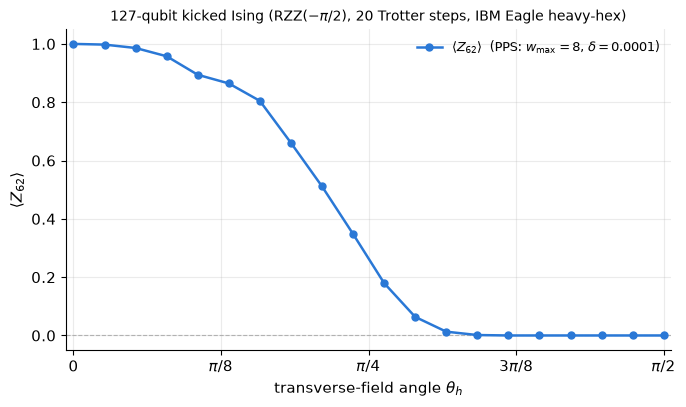

  -> wrote examples/figures/fig_kicked_ising_127q_notebook.png

field sweep (20 points), <Z_62>:
    h=0.00000 (0.0000pi)  <Z>=+1.000000  terms=1
    h=0.08267 (0.0263pi)  <Z>=+0.997629  terms=1
    h=0.16535 (0.0526pi)  <Z>=+0.986050  terms=2
    h=0.24802 (0.0789pi)  <Z>=+0.957642  terms=9
    h=0.33069 (0.1053pi)  <Z>=+0.894161  terms=10
    h=0.41337 (0.1316pi)  <Z>=+0.864488  terms=30
    h=0.49604 (0.1579pi)  <Z>=+0.804626  terms=32
    h=0.57871 (0.1842pi)  <Z>=+0.660705  terms=60
    h=0.66139 (0.2105pi)  <Z>=+0.511478  terms=55
    h=0.74406 (0.2368pi)  <Z>=+0.348135  terms=47
    h=0.82673 (0.2632pi)  <Z>=+0.179611  terms=34
    h=0.90941 (0.2895pi)  <Z>=+0.063677  terms=20
    h=0.99208 (0.3158pi)  <Z>=+0.013022  terms=1
    h=1.07476 (0.3421pi)  <Z>=+0.001464  terms=1
    h=1.15743 (0.3684pi)  <Z>=+0.000000  terms=0
    h=1.24010 (0.3947pi)  <Z>=+0.000000  terms=0
    h=1.32278 (0.4211pi)  <Z>=+0.000000  terms=0
    h=1.40545 (0.4474pi)  <Z>=+0.000000  terms=0
    h=1.48812

In [5]:
hs_plot = [r["h"] for r in data]
evs_plot = [r["ev"] for r in data]

fig, ax = plt.subplots()
ax.plot(hs_plot, evs_plot, marker="o", color=PALETTE[0], lw=1.8, ms=5,
        label=(fr"$\langle Z_{{{CENTER}}}\rangle$  (PPS: $w_{{\max}}={MAX_WEIGHT}$, "
               fr"$\delta={MIN_ABS}$)"))
ax.axhline(0.0, color="0.7", lw=0.8, ls="--", zorder=0)
ax.set_xlabel(r"transverse-field angle $\theta_h$")
ax.set_ylabel(fr"$\langle Z_{{{CENTER}}}\rangle$")
ax.set_xlim(-0.02, np.pi / 2 + 0.02)
ax.set_xticks([0, np.pi / 8, np.pi / 4, 3 * np.pi / 8, np.pi / 2])
ax.set_xticklabels(["0", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"])
ax.set_title(fr"{N}-qubit kicked Ising ($\mathrm{{RZZ}}(-\pi/2)$, "
             f"{NUM_STEPS} Trotter steps, IBM Eagle heavy-hex)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
out_png = FIGS / "fig_kicked_ising_127q_notebook.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"  -> wrote {out_png.relative_to(NB_DIR.parent)}")

print(f"\nfield sweep ({len(data)} points), <Z_{CENTER}>:")
for r in data:
    print(f"    h={r['h']:.5f} ({r['h_over_pi']:.4f}pi)  <Z>={r['ev']:+.6f}"
          f"  terms={r['zero_filtered_terms']}")

## Notes on reading this result

- **The endpoints are exact by construction, not by luck.** At `h = 0` every field rotation is
  the identity, the whole circuit is Clifford, and `Z_62` propagates back to a single Pauli
  term: `<Z_62> = 1` exactly. At `h = pi/2` the field layer is Clifford as well, so that
  endpoint is a Clifford point. Any truncation error has to vanish at both ends, which
  is why the endpoints are a sanity check and not evidence about the interior.
- **There is no exact reference at n = 127.** A statevector needs 2^127 amplitudes, so nothing
  here is validated against ground truth at full size — the 9-qubit patch in section 2 is
  what validates the conventions and the heavy-hex edge list, and the 127-qubit curve is a
  *qualitative* reproduction of the Rudolph et al. benchmark (same `max_weight = 8` and
  `min_abs_coeff = 1e-4`). Treat the interior of the curve as a truncated estimate, not as
  a verified value.
- **The per-field seconds printed above depend on the hardware.** A single notebook run
  measures one sample on whatever GPU is attached, with no warm-up control. Repeat-timing
  runs are under `reproducibility/repeat_timing/`.
- **What this notebook wrote:** `kicked_ising_127q/results/kicked_ising_127q_notebook.json`
  and `examples/figures/fig_kicked_ising_127q_notebook.png`. The recorded
  `kicked_ising_127q/results/*.json` and `kicked_ising_127q/figures/*` are regenerated with
  `run_sweep.sh` / `make_figure.py` / `verify_small.py`.